# A1 — Graphene vacuum convergence

Companion notebook to Advanced chapter A1. We check how the total energy of
a graphene monolayer depends on the vacuum thickness `c`, with
`assume_isolated='2D'` on. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

RY_TO_MEV = 13605.693
NAT = 2
d = Path('../code/advanced/01-2d-cell')
c, E = np.loadtxt(d/'vac.dat', skiprows=1, unpack=True)
dE = (E - E[-1]) / NAT * RY_TO_MEV   # meV/atom vs the largest box
for ci, yi in zip(c, dE):
    print(f'c = {ci:2.0f} Ang :  {yi:+.3f} meV/atom')

c = 14 Ang :  -0.027 meV/atom
c = 18 Ang :  +0.003 meV/atom
c = 22 Ang :  +0.018 meV/atom
c = 26 Ang :  +0.019 meV/atom
c = 30 Ang :  +0.000 meV/atom


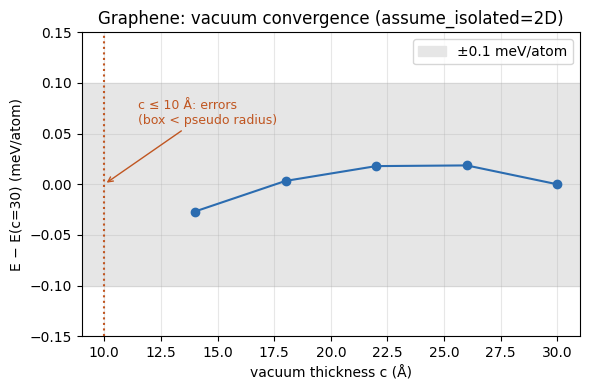

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhspan(-0.1, 0.1, color='0.9', label='±0.1 meV/atom')
ax.plot(c, dE, 'o-', color='#2b6cb0')
ax.axvline(10, ls=':', color='#c05621')
ax.annotate('c ≤ 10 Å: errors\n(box < pseudo radius)', xy=(10, 0.0),
            xytext=(11.5, 0.06), color='#c05621', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#c05621'))
ax.set_xlabel('vacuum thickness c (Å)')
ax.set_ylabel('E − E(c=30) (meV/atom)')
ax.set_title('Graphene: vacuum convergence (assume_isolated=2D)')
ax.set_ylim(-0.15, 0.15)
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(d.parent.parent.parent/'static/img/A1-vacuum.png', dpi=120)
plt.show()

**What you see.** With `assume_isolated='2D'` the energy is **flat to
well under 0.1 meV/atom** across the whole range — the cutoff-Coulomb
correction removes the periodic-image interaction analytically, so the
sheet is already 'isolated' at modest vacuum (~14–15 Å). But there is a
hard floor: below ~10 Å the run *errors* (`2D cutoff smaller than pseudo
cutoff radius`) — the box must be taller than the pseudopotential's cutoff
radius. The practical choice (`c = 20 Å`) sits comfortably above the floor
with energy fully converged.